## Synch - Kuramoto order parameter (hum.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#from matplotlib.animation import FuncAnimation
%matplotlib inline
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.io import loadmat
import scipy.io as sio
from scipy.signal import hilbert
import os
from os.path import isfile,isdir,join
from os import listdir

### Read data

In [2]:
df = pd.read_parquet ('data/datos_peso_01_11_2021_07_11_2021.pqt')

In [3]:
df.shape

(447675, 23)

In [4]:
pd.options.display.float_format = '{:.8g}'.format

In [5]:
df.describe()

,DiscosVida,DiscosDistancia,SiloFibraVelocidadPV,SiloRechazosVelocidadPV,FormadoraVelocidadPV,ScalperPosPV,ScalperReservaMediaPV,FormacionVelocidad,ColaSecaMaderaSecaPV,ParafinaSecaMaderaSecaPV,...,Etapa2MWHumedadPV,Etapa2MWHumedadSP,FormacionNIRHumedadPV,FormacionNIRResina,PreprensaEntPosPV,PreprensaEntPresionPV,PreprensaSalPosPV,PreprensaSalPresionPV,PreprensaPrecompresorPosPV,BasculaMantaPesoPV
count,447675,447675,447675,447675,447675,447675,447675,447675,447675,447675,...,447675,447675,447675,447675,447675,447675,447675,447675,447675,447675
mean,59.27621,16.411202,25.151165,10.845613,49.368967,448.44043,64.542295,274.76008,13.931567,1.0566297,...,12.55068,9.7271702,8.499579,13.834853,52.689812,200.7425,27.098561,183.15423,422.66892,14.501445
std,33.832039,1.7422266,5.8709281,20.418793,9.1594965,120.23123,4.8829994,98.683851,3.856951,0.55173119,...,1.2900299,1.0130007,0.66364796,3.5928883,19.374581,8.3074776,11.828563,9.3376275,121.46391,4.0311035
min,0.2480556,13.71765,1.1,0,20.2,189.755,36.43852,56.3,0,0,...,0,7.2,6.000023,-3.86144,16.555,8.113304,5.797501,8.754166,156.0242,3.070233
25%,25.39375,15.16471,20.7,0,42.8,394.1,62.318335,204.9,10.02115,0.51092855,...,11.99372,9.3,8.093525,10.45605,40.93251,196.7829,19.585,178.0056,367.5085,11.950995
50%,67.86667,16.12451,24.7,0,50.1,444.34,64.75389,269.9,12.51433,0.8994089,...,12.76784,9.8,8.53642,12.89519,50.47501,202.0379,25.0325,185.5678,420.3794,13.98755
75%,89.25278,16.68431,29.9,30,54.9,500.9424,67.53542,310.1,18.00632,1.711294,...,13.38549,10.2,8.911151,17.73373,58.35001,205.6909,31.03001,189.2848,472.2893,15.75943
max,109.4083,19.78333,35,100,84.1,750.965,86.66908,600.3,23.79606,2.13239,...,19.08274,13.8,11.47554,21.81494,107.04,273.558,101.52,262.343,834.6963,24.11803


In [48]:
index_ini = 342000
index_fin = 348000
window = 60
lag = 0

In [49]:
varA = df['FormacionNIRHumedadPV'].iloc[index_ini:index_fin].rolling(window).mean()-df['FormacionNIRHumedadPV'].iloc[index_ini:index_fin].mean()
varA = varA.dropna(how='any')
varA = varA.reindex()
time = varA.index
varA = np.concatenate((varA[::-1], varA))

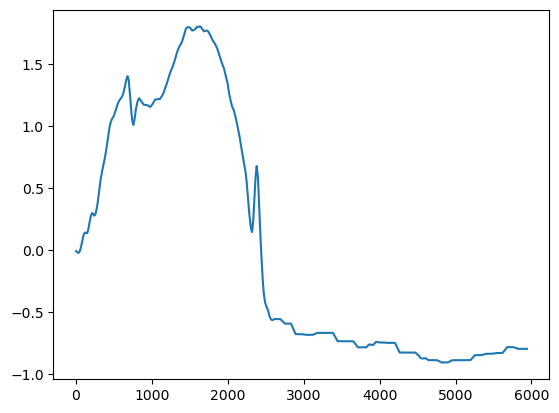

In [50]:
plt.plot(varA[len(time):])

In [51]:
varB = df['Etapa2MWHumedadPV'].iloc[index_ini-lag:index_fin-lag].rolling(window).mean()- df['Etapa2MWHumedadPV'].iloc[index_ini-lag:index_fin-lag].mean()
varB = varB.dropna(how='any')
varB = varB.reindex()
varB = np.concatenate((varB[::-1], varB))

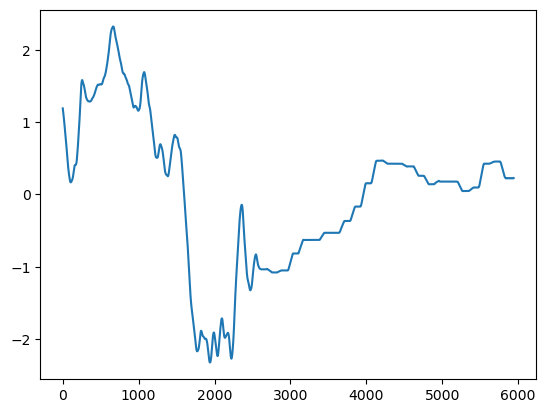

In [52]:
plt.plot(varB[len(time):])

### Recurrence plot

In [53]:
def recurrence_plot(data, threshold=0.1):
    """
    Recurrence plot from a time series
    
    :param data: Time series data
    :param threshold: Threshold to determine recurrence
    :return: Recurrence plot
    """
    # Calculate the distance matrix
    N = len(data)
    distance_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            distance_matrix[i,j] = np.abs(data[i] - data[j])
            
    # Create the recurrence plot
    recurrence_plot = np.where(distance_matrix <= threshold, 1, 0)
    
    return recurrence_plot

<function matplotlib.pyplot.show(close=None, block=None)>

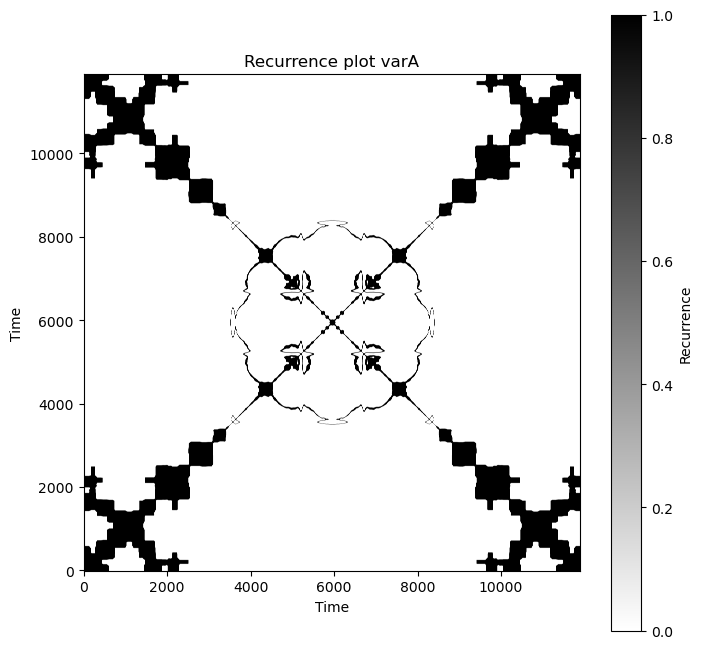

In [54]:
recA = recurrence_plot(varA, threshold=0.05)

plt.figure(figsize=(8, 8))
plt.imshow(recA, cmap='binary', origin='lower')
plt.title('Recurrence plot varA')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

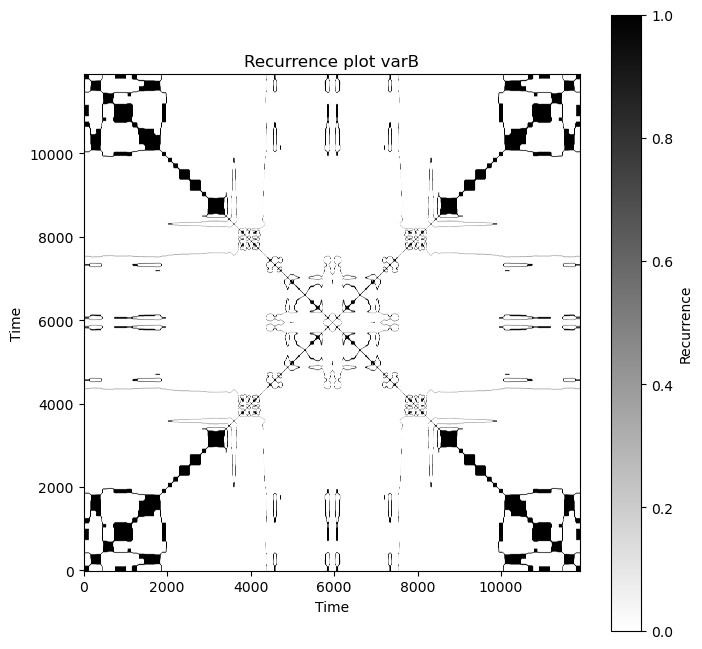

In [55]:
recB = recurrence_plot(varB, threshold=0.05)

plt.figure(figsize=(8, 8))
plt.imshow(recB, cmap='binary', origin='lower')
plt.title('Recurrence plot varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

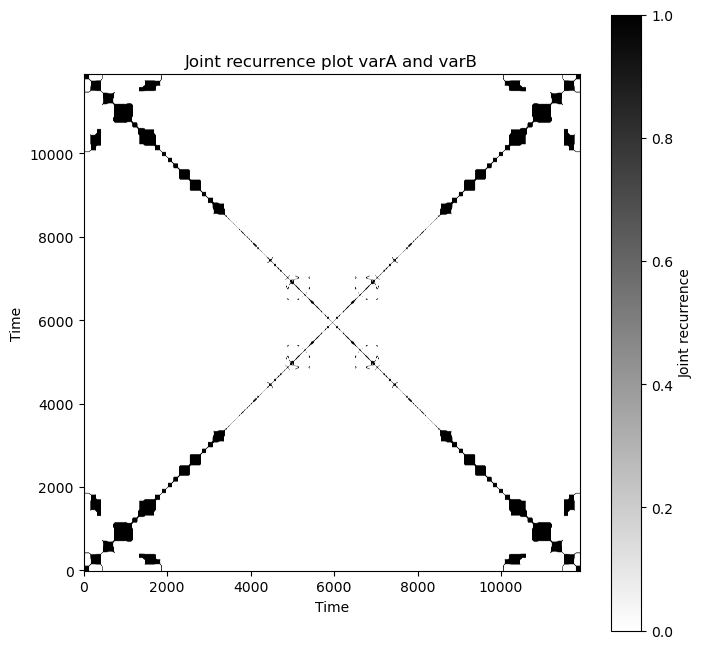

In [56]:
joint_rec = recA*recB

plt.figure(figsize=(8, 8))
plt.imshow(joint_rec, cmap='binary', origin='lower')
plt.title('Joint recurrence plot varA and varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Joint recurrence')
plt.show

### Alignement

In [96]:
index_ini = 342000
index_fin = 348000
window = 60
lag = 400

In [97]:
varB = df['Etapa2MWHumedadPV'].iloc[index_ini-lag:index_fin-lag].rolling(window).mean()- df['Etapa2MWHumedadPV'].iloc[index_ini-lag:index_fin-lag].mean()
varB = varB.dropna(how='any')
varB = varB.reindex()
varB = np.concatenate((varB[::-1], varB))

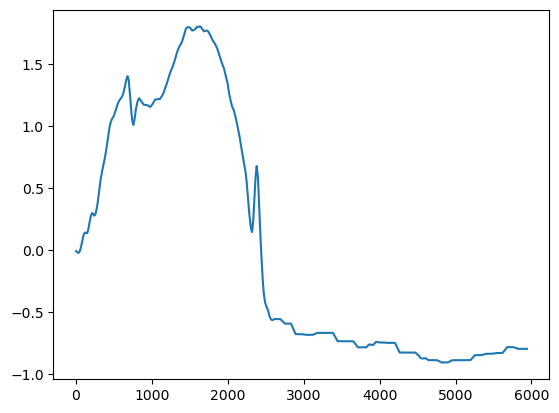

In [98]:
plt.plot(varA[len(time):])

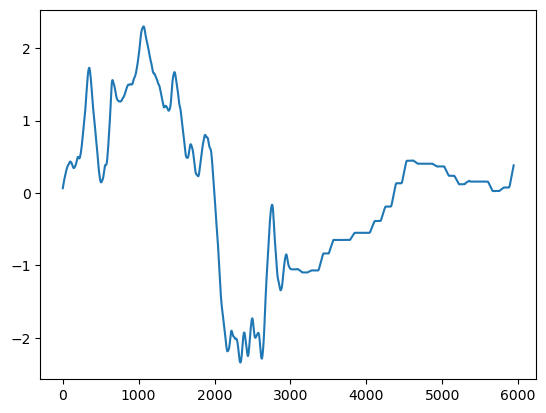

In [99]:
plt.plot(varB[len(time):])

### Hilbert transforms

Analytic signal:
$\zeta(t)=s(t)+i s_H(t)=A e^{i\phi(t)}$,

where:
- $A(t)$: instantaneous amplitude of the signal $s(t)$
- $\phi(t)$: instantaneous phase of the signal $s(t)$
- $s_H(t)=\frac{1}{\pi} P.V. \int_{-\infty}^{\infty} \frac{s(\tau)}{t-\tau} d\tau$: Hilbert transform of the signal $s(t)$

In [100]:
hil_evol_A = hilbert(varA)
hil_evol_A = hil_evol_A[len(time):]

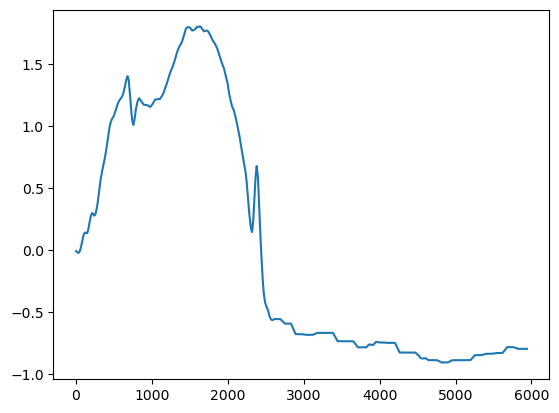

In [101]:
plt.plot(hil_evol_A.real)

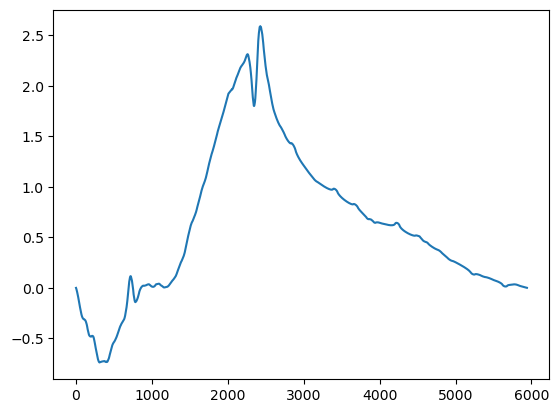

In [102]:
plt.plot(hil_evol_A.imag)

In [103]:
hil_evol_B = hilbert(varB)
hil_evol_B = hil_evol_B[len(time):]

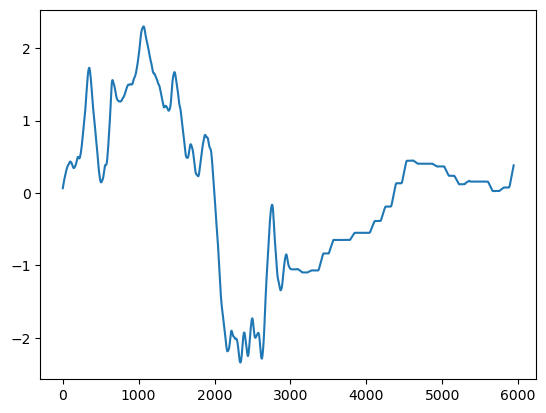

In [104]:
plt.plot(hil_evol_B.real)

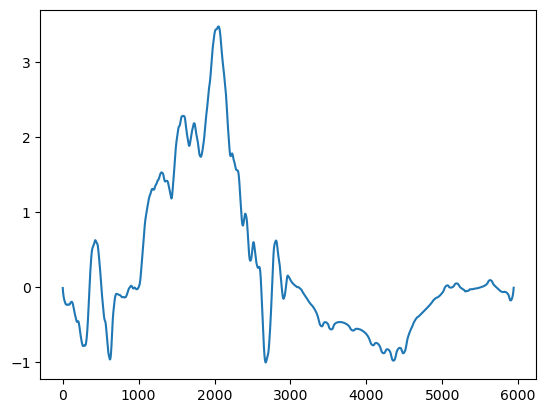

In [105]:
plt.plot(hil_evol_B.imag)

### Phases

In [106]:
ph_evol_A = np.arctan2(hil_evol_A.imag, hil_evol_A.real)

In [107]:
ph_evol_B = np.arctan2(hil_evol_B.imag, hil_evol_B.real)

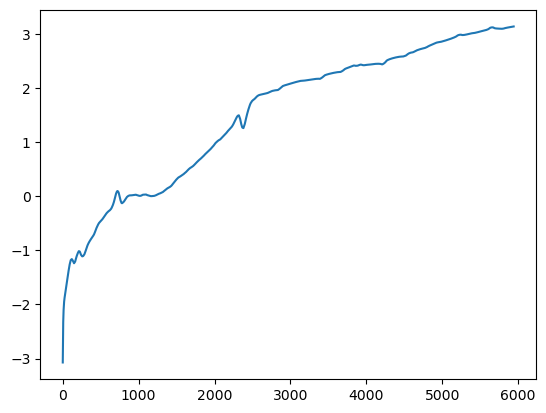

In [108]:
plt.plot(ph_evol_A)

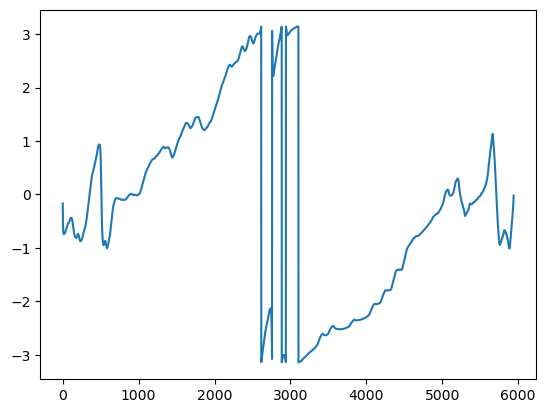

In [109]:
plt.plot(ph_evol_B)

### Kuramoto order parameter

In [110]:
R_A = np.exp(1j*ph_evol_A)
R_A = np.abs(R_A)

In [111]:
R_B = np.exp(1j*ph_evol_B)
R_B = np.abs(R_B)

In [112]:
R = (np.exp(1j*ph_evol_A)+np.exp(1j*ph_evol_B))/2
R = np.abs(R)
R.mean()

0.6748481720735575

Text(0.5, 1.0, 'Kuramoto order parameter')

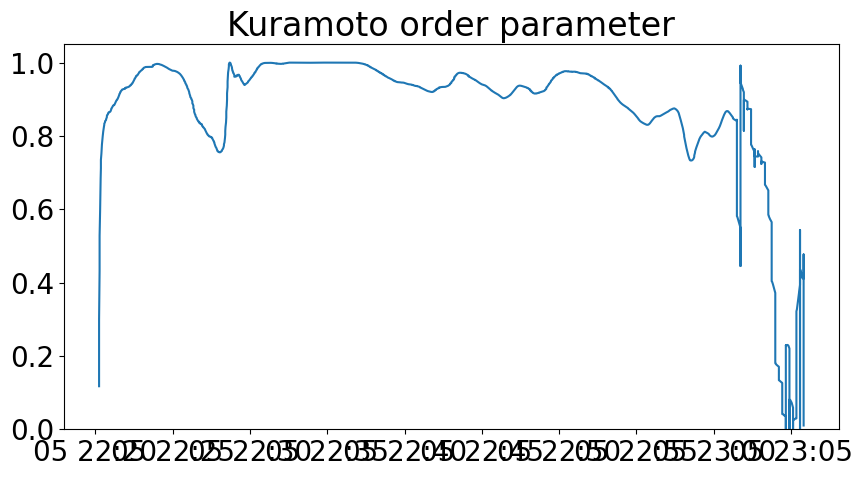

In [113]:
fig,ax = plt.subplots(figsize=(10,5))
plt.plot(time,R)
plt.ylim([0,1.05])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Kuramoto order parameter', fontsize=24)

### State space diagrams and phases plots

Text(0.5, 1.0, 'State space for phases')

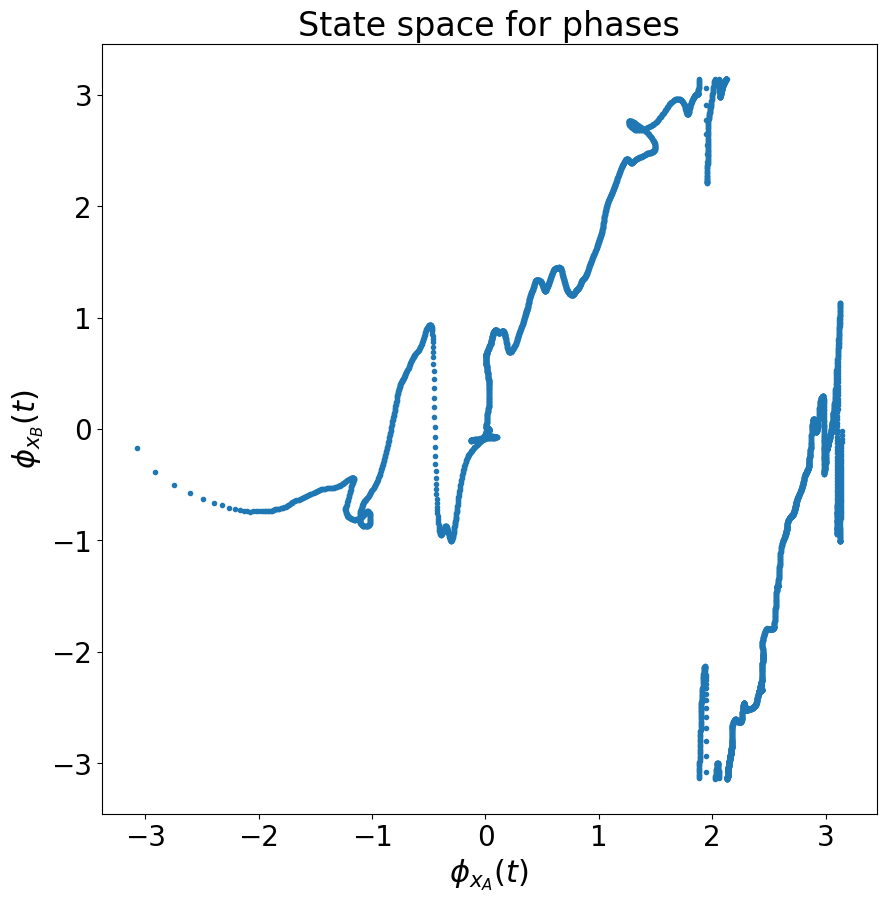

In [114]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(ph_evol_A,ph_evol_B,'.')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\phi_{x_A} (t)$', fontsize=22)
plt.ylabel('$\phi_{x_B} (t)$', fontsize=22)
plt.title('State space for phases', fontsize=24)

In [115]:
theta = np.linspace(-np.pi, np.pi, 100)

Text(0.5, 1.0, 'Phases')

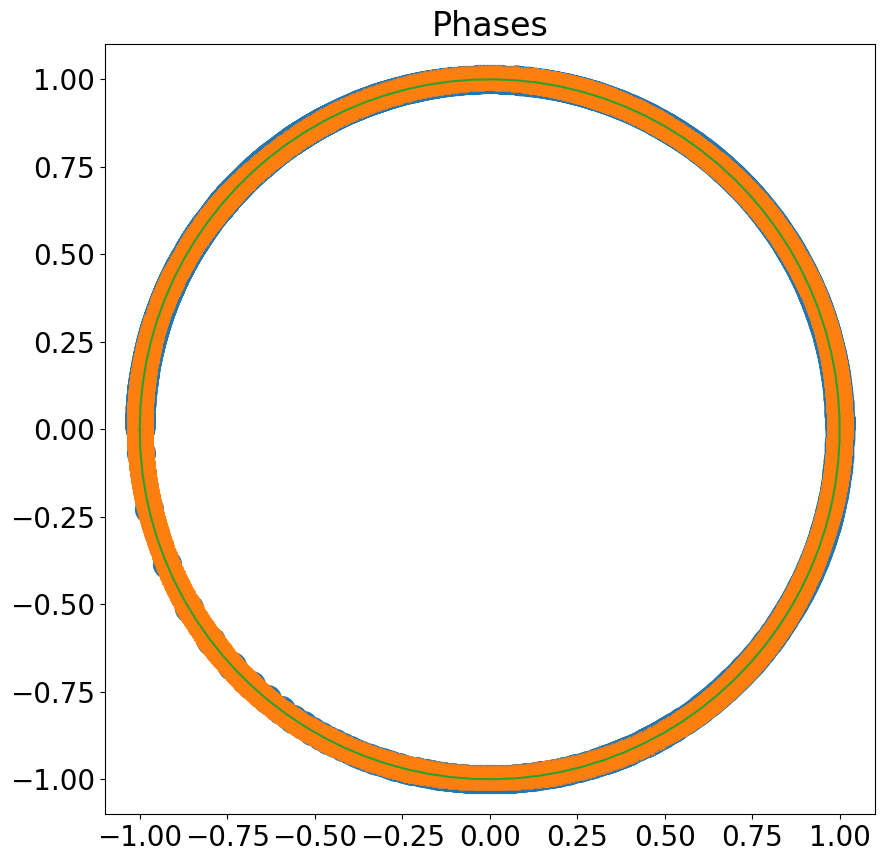

In [116]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(np.cos(ph_evol_A),np.sin(ph_evol_A),'o',np.cos(ph_evol_B),np.sin(ph_evol_B),'*',np.cos(theta), np.sin(theta), '-', markersize=20)
ax.set_aspect(1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phases', fontsize=24)
#plt.savefig('figures/phases.pdf')


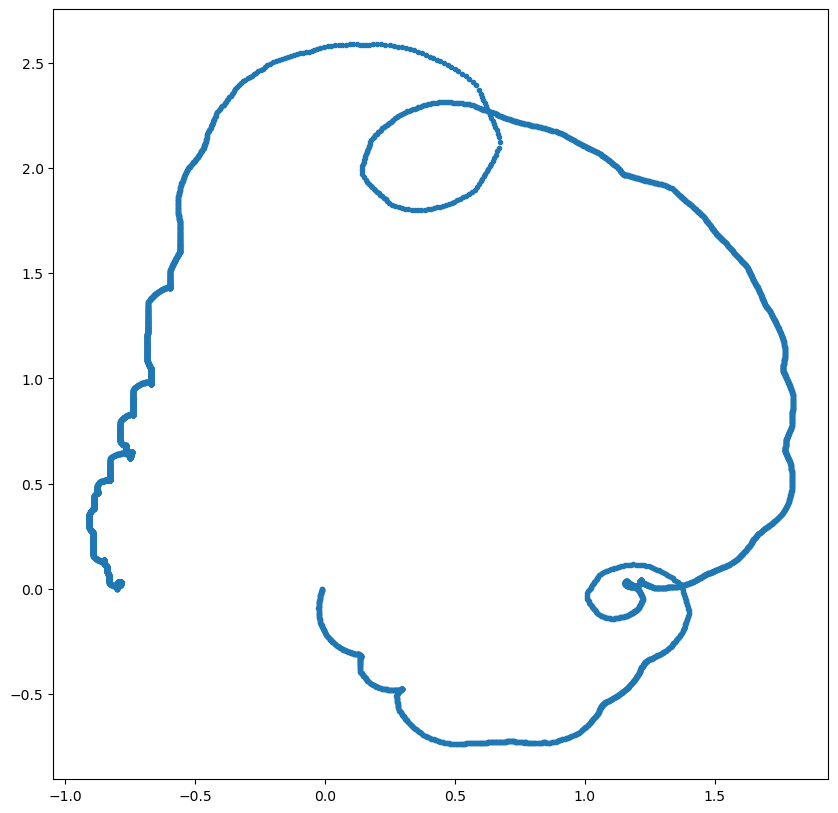

In [117]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(hil_evol_A.real,hil_evol_A.imag,'.')
#ax.set_aspect(1)

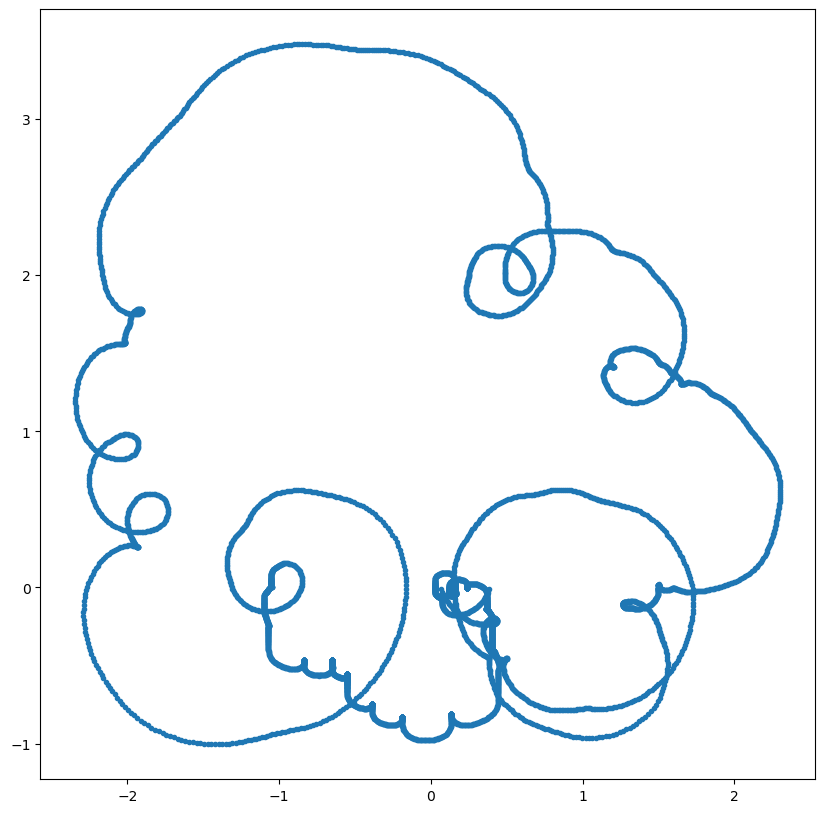

In [118]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(hil_evol_B.real,hil_evol_B.imag,'.')
#ax.set_aspect(1)

In [119]:
phA_B=np.arctan2(hil_evol_A.imag*hil_evol_B.real-hil_evol_A.real*hil_evol_B.imag, hil_evol_A.real*hil_evol_B.real+hil_evol_A.imag*hil_evol_B.imag)

Text(0.5, 1.0, 'Phase difference')

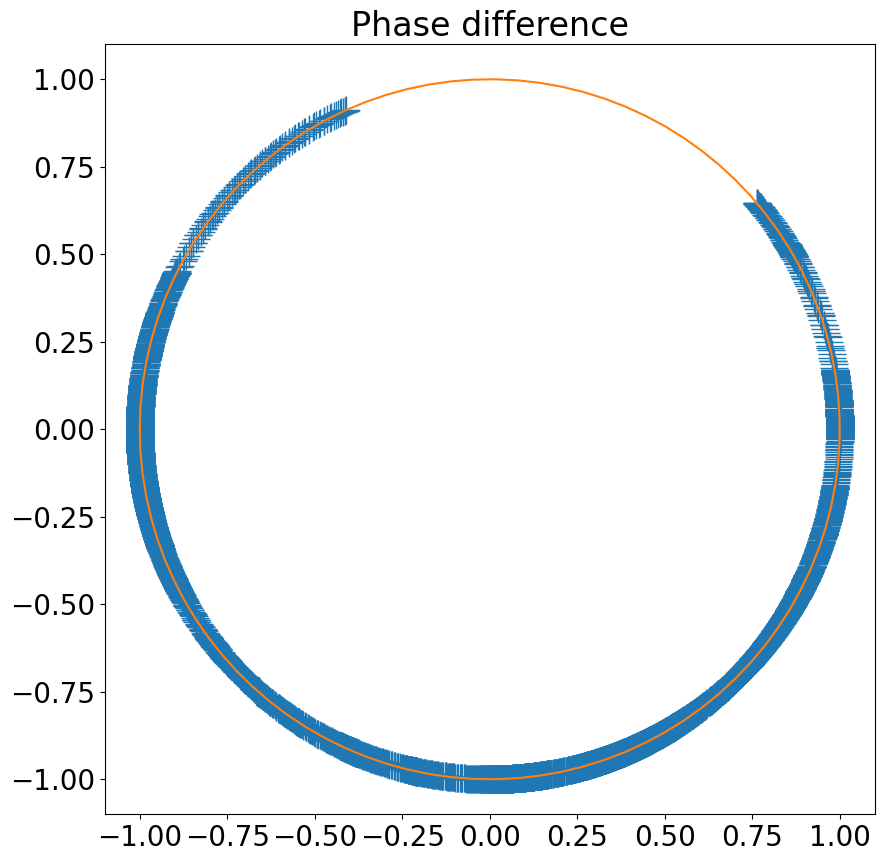

In [120]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(np.cos(phA_B),np.sin(phA_B),'+',np.cos(theta), np.sin(theta), '-', markersize=20)
ax.set_aspect(1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phase difference', fontsize=24)
#plt.savefig('figures/phases_diff_circ.pdf')

Text(0.5, 1.0, 'Phase difference')

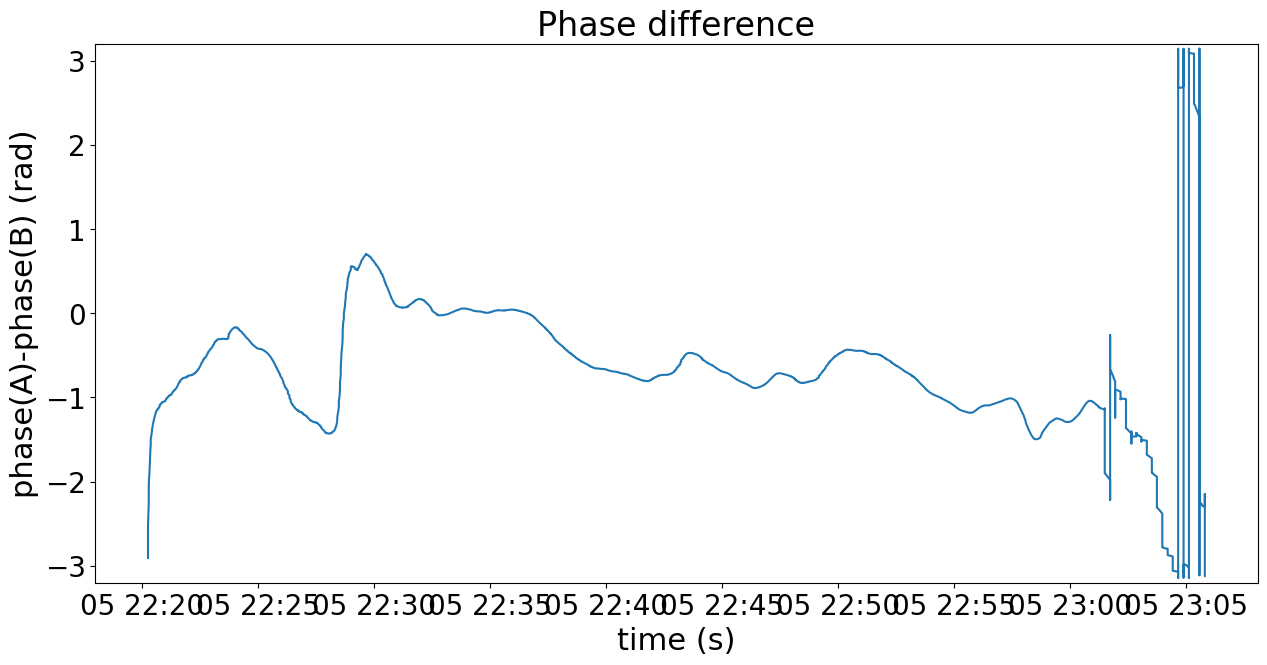

In [121]:
fig,ax = plt.subplots(figsize=(15,7))
plt.plot(time,(phA_B), '-', markersize=20)
plt.ylim([-3.2,3.2])
plt.xlabel('time (s)', fontsize=22)
plt.ylabel('phase(A)-phase(B) (rad)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phase difference', fontsize=24)
#plt.savefig('figures/phases_diff.pdf')

### Phases animation

In [122]:
#fig = plt.figure(figsize=(10,5))
#ax1 = plt.subplot(1,2,1)   
#ax2 = plt.subplot(1,2,2)
#ax1.plot(np.cos(theta), np.sin(theta), 'g-', markersize=20)
#ax2.plot(np.cos(theta), np.sin(theta), 'g-', markersize=20)
#ax1.set_aspect(1)
#ax2.set_aspect(1)
#ax1.tick_params(axis='both',labelsize=20)
#ax2.tick_params(axis='both',labelsize=20)
#ax1.set_xlabel('$\cos(\phi)$', fontsize=22)
#ax1.set_ylabel('$\sin(\phi)$', fontsize=22)
#ax2.set_xlabel('$\cos(\phi)$', fontsize=22)
#ax2.set_ylabel('$\sin(\phi)$', fontsize=22)
#ax1.set_title('Phases', fontsize=24)
#ax2.set_title('Phase difference', fontsize=24)
#fig.tight_layout()
#pt1, = ax1.plot([], [], 'o', ms=10)
#pt2, = ax1.plot([], [], '*', ms=10)
#pt3, = ax2.plot([], [], 'k.', ms=20)
#plt.close()

In [123]:
# def drawframe(n):
#     x1 = np.cos(ph_evol_A[n])
#     y1 = np.sin(ph_evol_A[n])
#     x2 = np.cos(ph_evol_B[n])
#     y2 = np.sin(ph_evol_B[n])    
#     x3 = np.cos(phA_B[n])
#     y3 = np.sin(phA_B[n])
#     pt1.set_data(x1,y1)
#     pt2.set_data(x2,y2)
#     pt3.set_data(x3,y3)
#     return (pt1,pt2,pt3)

In [124]:
# from matplotlib import animation
# anim = animation.FuncAnimation(fig, drawframe, frames=len(time), interval=20, blit=False)

In [125]:
# from IPython.display import HTML
# HTML(anim.to_html5_video())

### Recurrence plot

<function matplotlib.pyplot.show(close=None, block=None)>

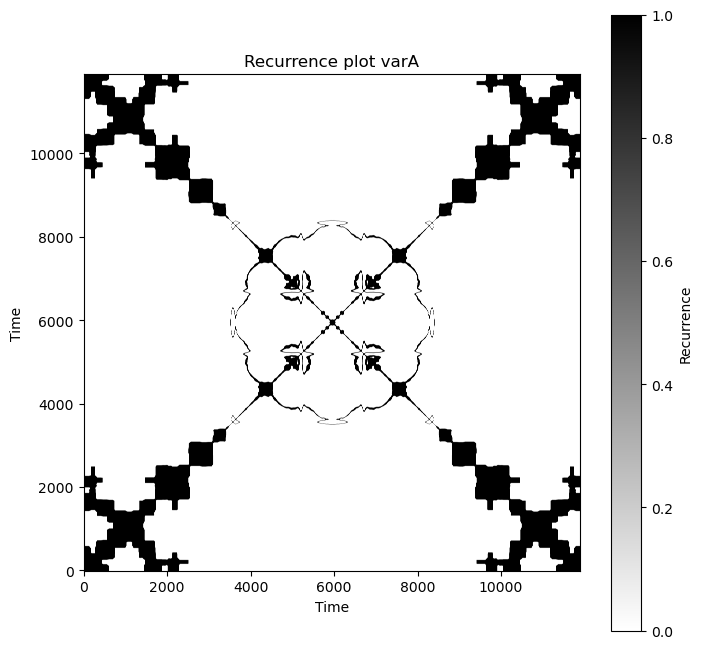

In [126]:
recA = recurrence_plot(varA, threshold=0.05)

plt.figure(figsize=(8, 8))
plt.imshow(recA, cmap='binary', origin='lower')
plt.title('Recurrence plot varA')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

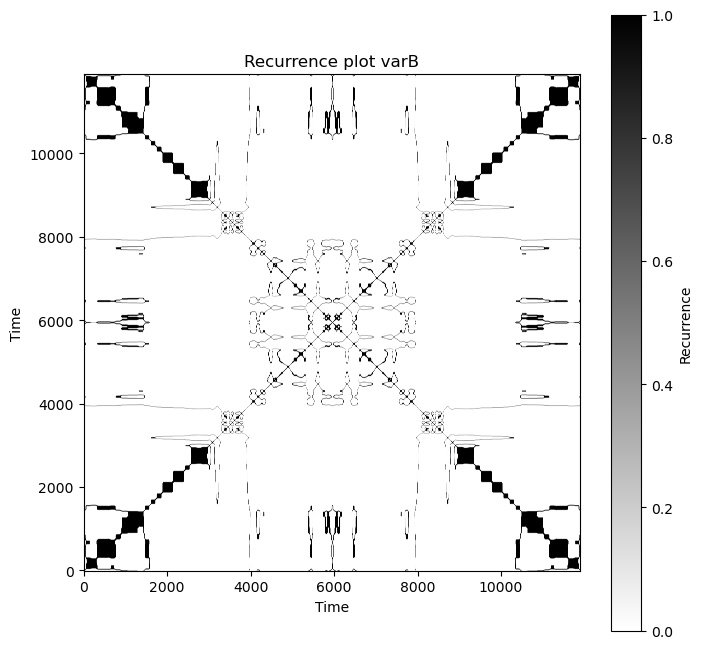

In [127]:
recB = recurrence_plot(varB, threshold=0.05)

plt.figure(figsize=(8, 8))
plt.imshow(recB, cmap='binary', origin='lower')
plt.title('Recurrence plot varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

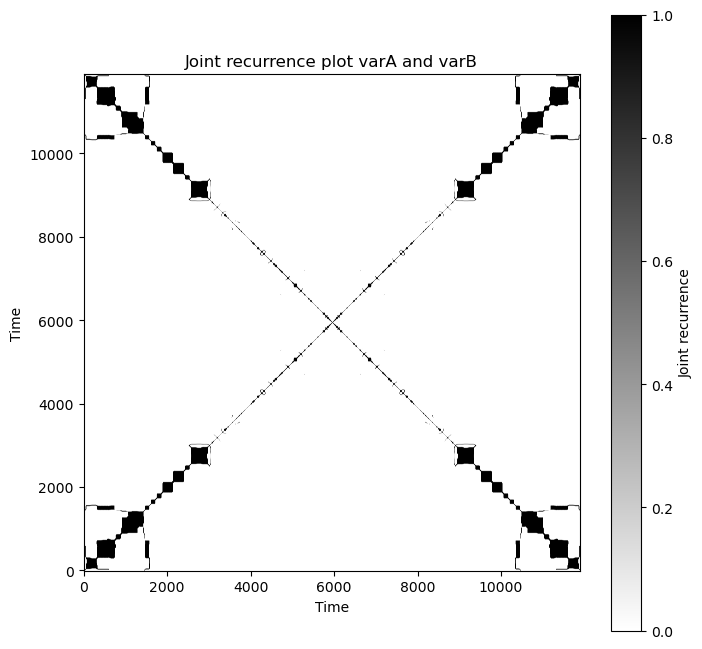

In [128]:
joint_rec = recA*recB

plt.figure(figsize=(8, 8))
plt.imshow(joint_rec, cmap='binary', origin='lower')
plt.title('Joint recurrence plot varA and varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Joint recurrence')
plt.show